#**22EyluLCase-1**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

In [2]:
df = pd.read_csv("winequality-red.csv", sep=";")

print("Veri seti boyutu:", df.shape)
print(df.head())
print(df.info())
print(df.describe())

Veri seti boyutu: (1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8   

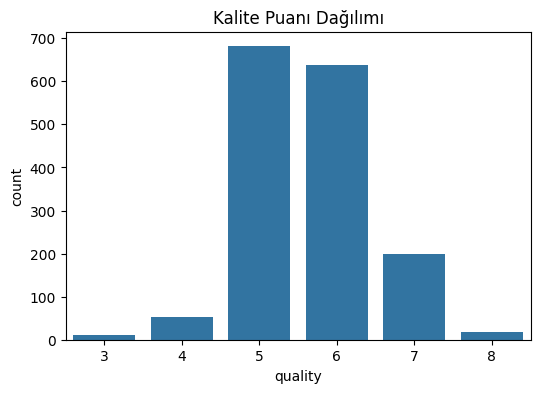

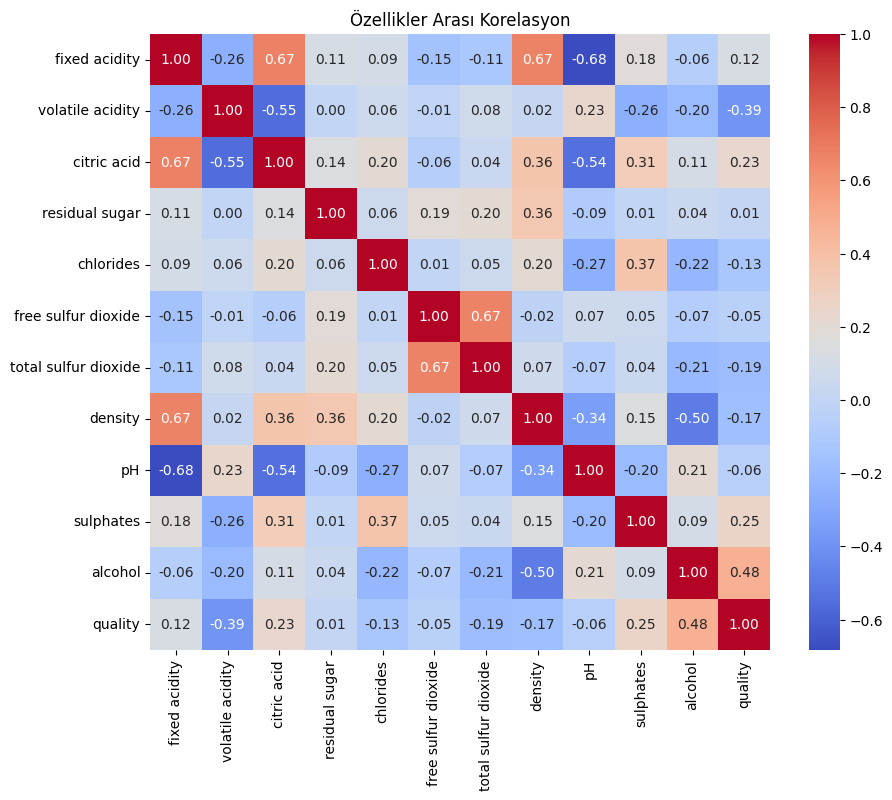

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x="quality", data=df)
plt.title("Kalite Puanı Dağılımı")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Özellikler Arası Korelasyon")
plt.show()

**1) LİNEER REGRESYON
  Amaç: "quality" (kalite puanı, sayısal) değerini tahmin etmek**

In [4]:
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Özellikleri ölçeklendirme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lin = lin_reg.predict(X_test_scaled)

In [7]:
mse = mean_squared_error(y_test, y_pred_lin)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lin)
r2 = r2_score(y_test, y_pred_lin)
#bu dördü (MSE, RMSE, MAE, R²) tamamen regresyon metrikleridir, sınıflandırmada kullanılmazlar

print("=== Lineer Regresyon Sonuçları ===")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R2   : {r2:.4f}")

=== Lineer Regresyon Sonuçları ===
MSE  : 0.3900
RMSE : 0.6245
MAE  : 0.5035
R2   : 0.4032


                 Özellik   Katsayı
10               alcohol  0.296628
1       volatile acidity -0.179439
9              sulphates  0.146815
6   total sulfur dioxide -0.120008
4              chlorides -0.089084
8                     pH -0.060610
5    free sulfur dioxide  0.058015
0          fixed acidity  0.039789
2            citric acid -0.027512
7                density -0.019204
3         residual sugar  0.009421


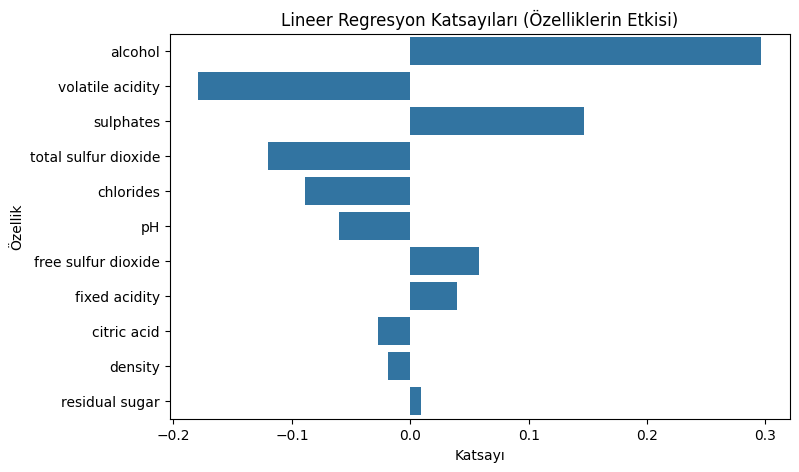

In [8]:
coef_df = pd.DataFrame({
    "Özellik": X.columns,
    "Katsayı": lin_reg.coef_
}).sort_values(by="Katsayı", key=abs, ascending=False)

print(coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(x="Katsayı", y="Özellik", data=coef_df)
plt.title("Lineer Regresyon Katsayıları (Özelliklerin Etkisi)")
plt.show()

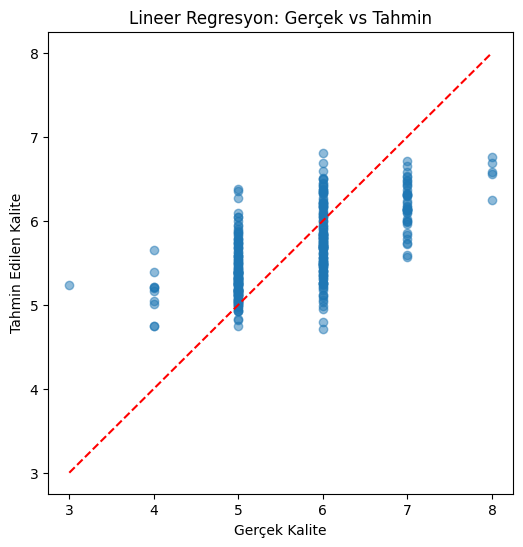

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Gerçek Kalite")
plt.ylabel("Tahmin Edilen Kalite")
plt.title("Lineer Regresyon: Gerçek vs Tahmin")
plt.show()

**2) LOJİSTİK REGRESYON
    Amaç: Şarabın "iyi" (quality >= 7) mi yoksa
    "iyi değil" (quality<7) mi olduğunu sınıflandırmak.
    Lojistik regresyon sürekli değil, ikili (binary) hedef
    ister; bu yüzden "quality" sütununu 0/1'e çeviriyoruz.**

In [11]:
df["quality_label"] = (df["quality"] >= 7).astype(int)

print(df["quality_label"].value_counts())

X2 = df.drop(["quality", "quality_label"], axis=1)
y2 = df["quality_label"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

quality_label
0    1382
1     217
Name: count, dtype: int64


In [12]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X2_train_scaled, y2_train)

y_pred_log = log_reg.predict(X2_test_scaled)
y_pred_proba = log_reg.predict_proba(X2_test_scaled)[:, 1]

In [13]:
acc = accuracy_score(y2_test, y_pred_log)
prec = precision_score(y2_test, y_pred_log)
rec = recall_score(y2_test, y_pred_log)
f1 = f1_score(y2_test, y_pred_log)
auc = roc_auc_score(y2_test, y_pred_proba)

In [14]:
print("=== Lojistik Regresyon Sonuçları ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print()
print(classification_report(y2_test, y_pred_log))


=== Lojistik Regresyon Sonuçları ===
Accuracy  : 0.8125
Precision : 0.4000
Recall    : 0.7907
F1 Score  : 0.5312
ROC-AUC   : 0.8824

              precision    recall  f1-score   support

           0       0.96      0.82      0.88       277
           1       0.40      0.79      0.53        43

    accuracy                           0.81       320
   macro avg       0.68      0.80      0.71       320
weighted avg       0.89      0.81      0.84       320



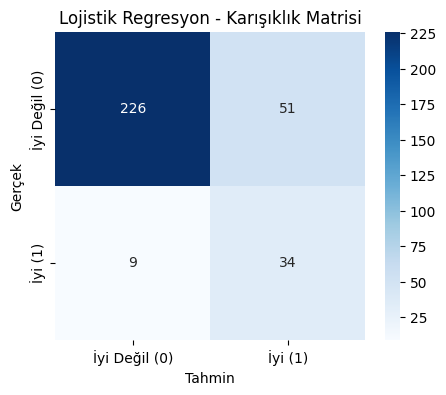

In [15]:
cm = confusion_matrix(y2_test, y_pred_log)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["İyi Değil (0)", "İyi (1)"],
            yticklabels=["İyi Değil (0)", "İyi (1)"])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Lojistik Regresyon - Karışıklık Matrisi")
plt.show()

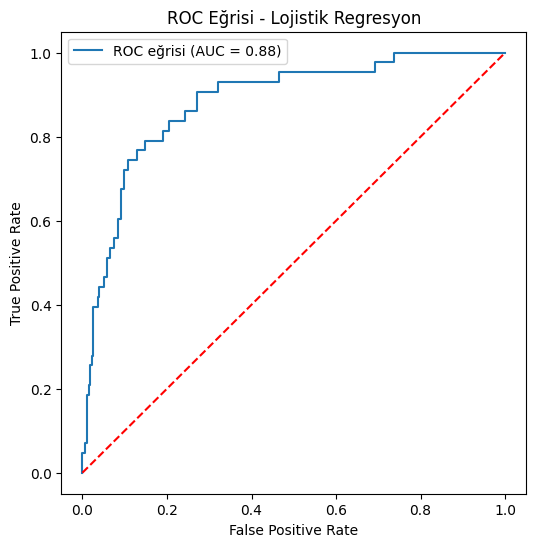

In [16]:
fpr, tpr, thresholds = roc_curve(y2_test, y_pred_proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC eğrisi (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrisi - Lojistik Regresyon")
plt.legend()
plt.show()

                 Özellik   Katsayı
10               alcohol  1.041861
6   total sulfur dioxide -0.823564
9              sulphates  0.653872
1       volatile acidity -0.448105
4              chlorides -0.343006
0          fixed acidity  0.323933
5    free sulfur dioxide  0.301230
7                density -0.284349
3         residual sugar  0.274038
8                     pH -0.150523
2            citric acid -0.011727


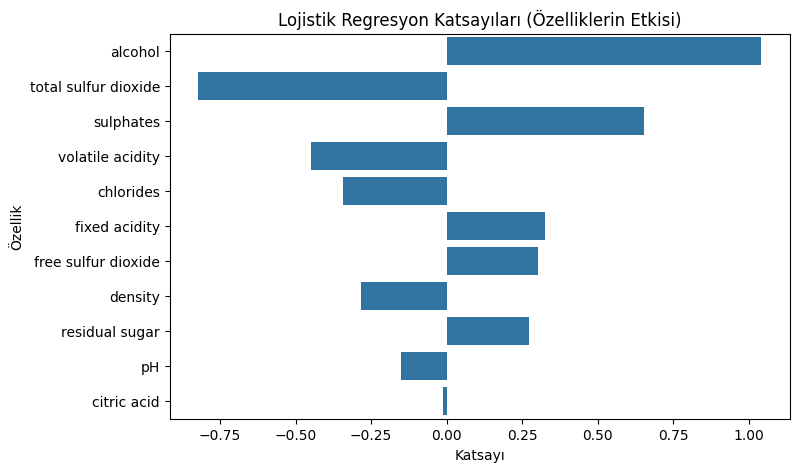

In [17]:
coef_df2 = pd.DataFrame({
    "Özellik": X2.columns,
    "Katsayı": log_reg.coef_[0]
}).sort_values(by="Katsayı", key=abs, ascending=False)

print(coef_df2)

plt.figure(figsize=(8, 5))
sns.barplot(x="Katsayı", y="Özellik", data=coef_df2)
plt.title("Lojistik Regresyon Katsayıları (Özelliklerin Etkisi)")
plt.show()